# PipeScraper 🔗 Advanced Examples

Welcome to **PipeScraper** 0.2.0! This notebook demonstrates the full capabilities of the library, including the new performance optimizations and updated integrations for `PipeFrame` and `PipePlotly` (v0.2.0).

## 🚀 1. Flash Scraping (New Default Performance)

In v0.2.0, default delays are reduced, and `newspaper4k's` slow time-extraction is disabled by default. This makes basic scraping significantly faster.

In [1]:
import time
from pipescraper import FetchLinks, ExtractArticles, ToDataFrame

url = "https://www.bbc.com/news"  # Example site
# url = "https://www.chroniclelive.co.uk/news/"  # Example site

start = time.time()
df = (url >> 
      FetchLinks(max_links=15, print_url=False) >> 
      ExtractArticles(workers=5) >> 
      ToDataFrame())
end = time.time()

print(f"Scraped {len(df)} articles in {end - start:.2f} seconds!")
display(df.head())

Scraped 15 articles in 6.45 seconds!


,url,source,title,text,description,author,date_published,time_published,language,tags,image_url
0,https://www.bbc.com/news/articles/c5y4e3pzvl0o,BBC News,Parents accused of hiding daughter's HIV infec...,Parents accused of hiding daughter's HIV infec...,The child did not see a doctor until she was s...,Paulin Kola,2026-03-12,16:58:22,,[],https://ichef.bbci.co.uk/news/1024/branded_new...
1,https://www.bbc.com/future/article/20260128-ho...,BBC,How to make Google put preferred sources up to...,How to make Google put preferred sources up to...,A new feature lets you choose which publishers...,BBC Staff,2026-01-28,17:30:00,,[],https://ychef.files.bbci.co.uk/624x351/p0mxnd5...
2,https://www.bbc.com/news/videos/c2e4ljy1kp8o,bbc.com,Volcanic fragments rain down as Hawaii's Kilau...,Volcanic fragments rain down as Hawaii's Kilau...,This eruption episode sent fragments made of a...,,2026-03-11,16:52:10,,[],https://ichef.bbci.co.uk/news/1024/branded_new...
3,https://www.bbc.com/news/live/cq6q8dgvp8zt,BBC News,Live updates: Suspect dead after attack at Tem...,FBI investigating 'targeted act of violence ag...,The suspect rammed a vehicle rammed into Templ...,Live Reporting Edited by Brandon Livesay; Oliv...,2026-03-12,17:22:03,,[],https://static.files.bbci.co.uk/core/website/a...
4,https://www.bbc.com/news/articles/c0j5lx75vg3o,BBC News,Nineteen jailed over Moscow's deadly Crocus Ci...,Nineteen jailed over deadly Moscow concert att...,Gunmen opened fire at Crocus City Concert hall...,Jessica Rawnsley,2026-03-12,12:00:27,,[],https://ichef.bbci.co.uk/news/1024/branded_new...


In [3]:
df.columns

Index(['url', 'source', 'title', 'text', 'description', 'author',
       'date_published', 'time_published', 'language', 'tags', 'image_url'],
      dtype='object')

In [4]:
df['url']

0         https://www.bbc.com/news/live/cq6q8dgvp8zt
1     https://www.bbc.com/news/articles/cy8lzn2ejpjo
2     https://www.bbc.com/news/articles/cy03jw2g78no
3     https://www.bbc.com/news/articles/cm2xrz71zm3o
4       https://www.bbc.com/news/world/latin_america
5     https://www.bbc.com/news/articles/cx28v2y7de2o
6     https://www.bbc.com/news/articles/cly2xynjzdzo
7       https://www.bbc.com/news/videos/cqxd7lyngxjo
8     https://www.bbc.com/news/articles/cvgkj148p7no
9     https://www.bbc.com/news/articles/cly09j2542no
10     https://www.bbc.com/news/wales/wales_politics
11        https://www.bbc.com/news/live/c4gqjyk0vx3t
12    https://www.bbc.com/news/articles/cn87ndvklr2o
13         https://www.bbc.com/news/world/asia/china
14    https://www.bbc.com/news/articles/ce3g49w5zxwo
Name: url, dtype: object

In [5]:
df[['date_published', 'time_published']]

,date_published,time_published
0,2026-03-12,17:22:03
1,2026-03-12,20:20:50
2,2026-03-11,22:51:08
3,2026-03-12,20:36:10
4,2026-02-25,
5,2026-03-12,20:53:35
6,2026-03-12,13:42:44
7,2026-03-12,00:20:34
8,2026-03-12,15:12:02
9,2026-03-12,12:15:26


In [6]:
df['title']

0     Live updates: Suspect dead after attack at Tem...
1     Emirati minister tells BBC Iran must end strik...
2     The Other Bennet Sister: Ruth Jones on playing...
3     Israel drops charges against soldiers accused ...
4      Latin America | Latest News & Updates | BBC News
5     BBC spends day with emergency teams as Israel ...
6     Sly fox sneaks on to cargo ship in Southampton...
7     Justified or not? US military families on fear...
8     Tewkesbury mother jailed for keeping woman as ...
9     Jo Malone sued by Estée Lauder for using her n...
10    Wales Politics | Latest News & Updates | BBC News
11    US military says rescue efforts under way afte...
12    Hozier, Jessie Buckley and Bruce Springsteen r...
13             China | Latest News & Updates | BBC News
14        What on earth is going on with the oil price?
Name: title, dtype: object

## 🎯 2. Precision Filtering and Cleaning

Chaining operations to get exactly the data you need.

In [7]:
from pipescraper import FilterArticles, LimitArticles, Deduplicate

# Scrape, ensure only articles with titles, remove duplicates, and limit to 3
articles = (url >> 
           FetchLinks(max_links=15) >> 
           ExtractArticles(workers=15) >> 
           FilterArticles(lambda a: len(a.title) > 10) >> 
           Deduplicate() >> 
           LimitArticles(15))

for a in articles:
    print(f"✅ {a.title} ({len(a.text)} chars)")

✅ Live updates: Suspect dead after attack at Temple Israel in West Bloomfield, Michigan (543 chars)
✅ Emirati minister tells BBC Iran must end strikes on Gulf (3060 chars)
✅ The Other Bennet Sister: Ruth Jones on playing Pride and Prejudice's Mrs Bennet (3207 chars)
✅ Israel drops charges against soldiers accused of abusing Gaza detainee (4111 chars)
✅ Latin America | Latest News & Updates | BBC News (5112 chars)
✅ BBC spends day with emergency teams as Israel strikes Lebanon (8048 chars)
✅ Sly fox sneaks on to cargo ship in Southampton and arrives in New York (2052 chars)
✅ Justified or not? US military families on fears of Iran war (498 chars)
✅ Tewkesbury mother jailed for keeping woman as slave for 25 years (5805 chars)
✅ Jo Malone sued by Estée Lauder for using her name in Zara collaboration (2818 chars)
✅ Wales Politics | Latest News & Updates | BBC News (2214 chars)
✅ US military says rescue efforts under way after refuelling plane crashes in Iraq - follow live (477 chars)
✅ Hoz

## 📊 3. PipeFrame Integration (dplyr-style)

PipeScraper 0.2.0 supports PipeFrame 0.2.0+. Use `ToPipeFrame` to enable powerful data manipulation.

In [8]:
try:
    from pipescraper import ToPipeFrame, select, mutate, arrange, filter_df
    
    result = (url >> 
              FetchLinks(max_links=10) >> 
              ExtractArticles(workers=5) >> 
              ToPipeFrame() >>
              select('title', 'author', 'text') >>
              mutate(wc=lambda df: df['text'].str.split().str.len()) >>
              arrange('wc', ascending=False) >> 
              filter_df(lambda df: df['wc'] > 50))

    display(result)
except ImportError:
    print("PipeFrame 0.2.0+ required.")

<pipeframe.DataFrame shape=(10, 4)>
                                               title  \
7  Justified or not? US military families on fear...   
0  Live updates: Suspect dead after attack at Tem...   
6  Sly fox sneaks on to cargo ship in Southampton...   
9  Jo Malone sued by Estée Lauder for using her n...   
1  Emirati minister tells BBC Iran must end strik...   
2  The Other Bennet Sister: Ruth Jones on playing...   
3  Israel drops charges against soldiers accused ...   
4   Latin America | Latest News & Updates | BBC News   
8  Tewkesbury mother jailed for keeping woman as ...   
5  BBC spends day with emergency teams as Israel ...   

                                              author  \
7                                                      
0  Live Reporting Edited by Brandon Livesay; Oliv...   
6                                     Brandon Drenon   
9                                       Faarea Masud   
1                                        Clive Myrie   
2          

## 📈 4. PipePlotly Integration (Grammar of Graphics)

Visualize your results immediately. Note the updated syntax for v0.2.0 compatibility.

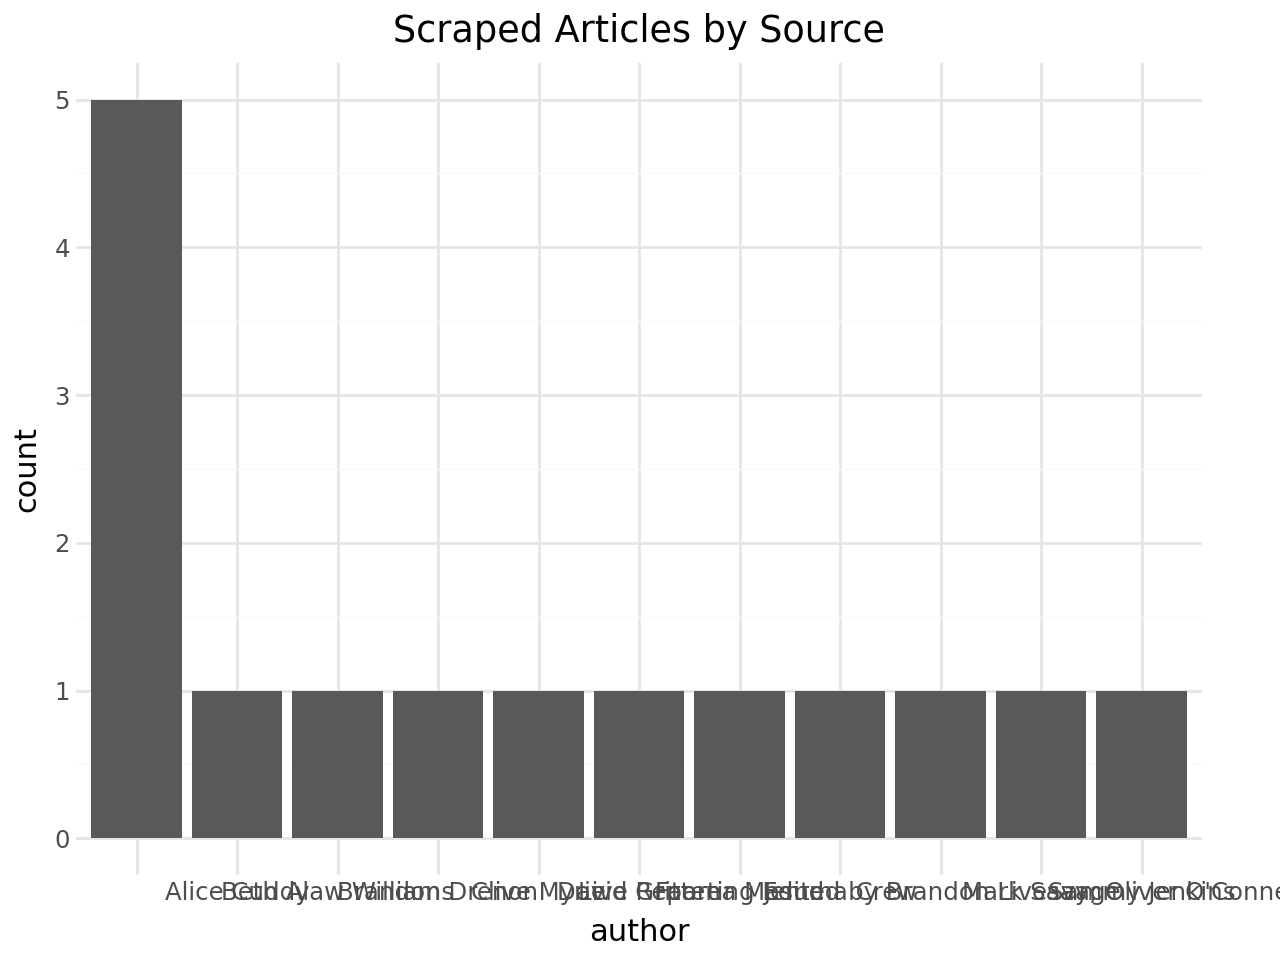

In [9]:
try:
    from pipescraper import ToPipeFrame, ggplot, geom_bar, labs, theme_minimal, show

    # Create a bar chart of sources
    (url >> 
     FetchLinks(max_links=15) >>
     ExtractArticles(workers=5) >>
     ToPipeFrame() >>
     ggplot() >>
     geom_bar(x='author') >>
     labs(title='Scraped Articles by Source') >>
     theme_minimal() >>
     show())
except Exception as e:
    print(f"Visualization error: {e}. Ensure PipePlotly 0.2.0+ is installed.")

## 📰 5. Google News Integration

Fetch top news stories directly from Google News. This uses `newspaper4k's` Google News source to retrieve URLs which are then passed through the PipeScraper pipeline.

In [2]:
# 🛠️ Setup dependencies for Google News
# if you see errors, UNCOMMENT the line below and run this cell.
# !pip install -U "newspaper4k[gnews]" gnews

import pipescraper
print(f"PipeScraper version: {pipescraper.__version__}")

try:
    from newspaper.google_news import GoogleNewsSource
    print("✓ newspaper4k[gnews] is correctly installed.")
except ImportError:
    print("✗ newspaper4k[gnews] is missing. Checking fallback...")
    try:
        from gnews import GNews
        print("✓ direct gnews package is available as fallback.")
    except ImportError:
        print("✗ Missing both newspaper4k[gnews] and gnews.")
        print("👉 Please uncomment the !pip install line above, run this cell, and RESTART your kernel.")

PipeScraper version: 0.2.3
✓ newspaper4k[gnews] is correctly installed.


In [1]:
from pipescraper import FetchGoogleNews, ExtractArticles, ToDataFrame

# Fetch top 10 news stories from the US in the last 24 hours
gnews_articles = (FetchGoogleNews(country="US", period="1d", max_results=20, print_url=False) >> 
                  ExtractArticles(workers=5) >> 
                  ToDataFrame())

print(f"Fetched {len(gnews_articles)} articles from Google News!")
if not gnews_articles.empty:
    display(gnews_articles)
else:
    print("No articles found. Check if newspaper4k[gnews] is installed and working.")

Fetched 10 articles from Google News!


,url,source,title,text,description,author,date_published,time_published,language,tags,image_url
0,https://www.cbsnews.com/detroit/news/police-re...,CBS Detroit,Suspect in Detroit-area synagogue attack is ki...,Suspect in Detroit-area synagogue attack is ki...,A suspect in an attack on a synagogue in the D...,Joseph Buczek,2026-03-12,13:01:00,,"[West Bloomfield, Active Shooter]",https://assets2.cbsnewsstatic.com/hub/i/r/2026...
1,https://www.cnn.com/world/live-news/iran-war-u...,CNN,Live updates: Iran threatens energy infrastruc...,Here's the latest • First purported message: A...,Iran has threatened to set oil and gas infrast...,Hira Humayun; Michael Rios; Nechirvan Mando; M...,2026-03-12,04:08:01,,[],https://media.cnn.com/api/v1/images/stellar/pr...
2,https://apnews.com/article/old-dominion-univer...,AP News,ROTC students at Old Dominion subdued and kill...,ROTC students at Old Dominion subdued and kill...,The FBI says the suspect has been identified a...,Jonathan Mattise; Olivia Diaz; Alanna Durkin R...,2026-03-12,16:01:31,,"[General news, Crime, Islamic State group, New...",https://dims.apnews.com/dims4/default/3c10e24/...
3,https://www.bbc.com/news/articles/c80j4rln8zmo,BBC News,How Iran war ship attacks choked off Strait of...,Tracking the wave of ship attacks that has cho...,Six ships have been reportedly attacked in the...,Kayleen Devlin; Daniele Palumbo; Joshua Cheeth...,2026-03-12,18:19:44,,[],https://ichef.bbci.co.uk/news/1024/branded_new...
4,https://www.nbcnews.com/politics/national-secu...,NBC News,Democrats ask Pentagon about Iran school strik...,WASHINGTON — More than 120 Democratic members ...,"In a letter to Defense Secretary Pete Hegseth,...",Courtney Kube,2026-03-12,15:00:40,,[],https://media-cldnry.s-nbcnews.com/image/uploa...
5,https://apnews.com/article/cyber-threats-iran-...,AP News,Iran-linked hackers take aim at US and other t...,Iran-linked hackers take aim at US and other t...,Pro-Iranian hackers are targeting sites in the...,David Klepper,2026-03-12,17:23:39,,"[Donald Trump, Michigan, Hacking, Donald Trump...",https://dims.apnews.com/dims4/default/b3da5f6/...
6,https://defector.com/live-nation-gets-to-keep-...,Defector,Live Nation Gets To Keep Its Monopoly Thanks T...,"On Monday, while the nation's attention was fo...","On Monday, while the nation’s attention was fo...",Patrick Redford,2026-03-12,17:53:21,,[],https://lede-admin.defector.com/wp-content/upl...
7,https://www.businessinsider.com/atlassian-layo...,Business Insider,Atlassian's CEO spelled out 3 types of employe...,- Atlassian CEO Mike Cannon-Brookes outlined t...,Atlassian highlighted graduates as a worker ca...,Brent D Griffiths,2026-03-12,16:29:43,,[],https://i.insider.com/69b2dc11a96e437d6eb8349b...
8,https://gizmodo.com/gemini-is-now-your-permane...,Gizmodo,Gemini Is Now Your Permanent Passenger in Goog...,Get ready to start seeing “Gemini is my copilo...,Hopefully it doesn't hallucinate directions.,AJ Dellinger,2026-03-12,18:20:45,,[],https://gizmodo.com/app/uploads/2026/03/Google...
9,https://www.theverge.com/ai-artificial-intelli...,The Verge,"Anthropic’s Claude AI can respond with charts,...",Anthropic’s latest update to Claude will allow...,Claude can now help you visualize topics as yo...,Emma Roth,2026-03-12,16:00:00,,"[theverge,pagetype:story,ai-artificial-intelli...",https://platform.theverge.com/wp-content/uploa...


### 🔍 5b. Search Google News

You can now search for specific keywords or sentences. If you provide a list of queries, PipeScraper will gather everything and automatically deduplicate the results.

In [2]:
# Search for a single topic or a list of sentences
search_articles = (FetchGoogleNews(search=["Iran-USA war", "latest middle east peace news"], 
                                  max_results=10, 
                                  print_url=False) >> 
                   ExtractArticles(workers=5) >> 
                   ToDataFrame())

print(f"Found {len(search_articles)} unique articles across all search terms!")
display(search_articles)

Found 7 unique articles across all search terms!


,url,source,title,text,description,author,date_published,time_published,language,tags,image_url
0,https://www.theguardian.com/commentisfree/2026...,The Guardian,Israel and the US are fighting Iran together. ...,When the US and Israel launched an attack on I...,The differences between what Trump and Netanya...,Yousef Munayyer,2026-03-12,00:00:00,,"[US-Israel war on Iran,Israel,Iran,Donald Trum...",https://i.guim.co.uk/img/media/4ceb29a473a210d...
1,https://www.pbs.org/newshour/world/iran-linked...,PBS News,Iran-linked hackers take aim at U.S. and other...,"By — David Klepper, Associated Press David Kle...",Hackers supporting Iran claimed responsibility...,,2026-03-12,17:20:30,,"[cyberattacks, hackers, iran, iran attacks]",https://d3i6fh83elv35t.cloudfront.net/static/2...
2,https://www.cnn.com/2026/03/12/middleeast/trum...,CNN,Trump may be unable to end the war he started ...,A war that is “won” but also “not finished yet...,A war that is “won” but also “not finished yet...,Nick Paton Walsh,2026-03-12,00:00:00,,[],https://media.cnn.com/api/v1/images/stellar/pr...
3,https://www.cfr.org/articles/report-says-u-s-s...,Council on Foreign Relations,Report Says U.S. Struck Iran School | Council ...,Report Says U.S. Struck Iran School By experts...,"Welcome to the Daily News Brief, CFR’s flagshi...",,2026-03-12,10:42:39,,[],https://res.cloudinary.com/dmovl8u5q/images/f_...
4,https://www.middleeasteye.net/news/trump-admin...,Middle East Eye,White House now says Iran 'never' threatened U...,Trump administration under attack from all sid...,Administration slammed on the left and the rig...,Sean Mathews,2026-03-12,21:00:55,,[],https://www.middleeasteye.net/sites/default/fi...
5,https://www.euronews.com/my-europe/2026/03/12/...,Euronews,Tehran claims US-Israeli strikes have 'no impa...,Iran's Foreign Minister Seyed Abbas Araghchi a...,Iran's Foreign Minister Seyed Abbas Araghchi a...,Estelle Nilsson-Julien,2026-03-12,00:00:00,,"[Israel Iran conflict,US-Israel attack on Iran...",https://images.euronews.com/articles/stories/0...
6,https://www.theguardian.com/commentisfree/2026...,The Guardian,The war in Iran is an American failure. What d...,As we reach the 13th day of the war in Iran – ...,The most powerful nation in the world is now b...,Robert Reich,2026-03-12,00:00:00,,"[Donald Trump,US news,Trump administration,Ira...",https://i.guim.co.uk/img/media/c10aabf2d487fa1...


## 🤖 6. Custom Requests & Headers

Impersonate different browsers or add custom delays for respectful scraping.

In [8]:
from pipescraper import FetchLinks, ExtractArticles

custom_ua = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"

fast_scrape = (url >> 
               FetchLinks(user_agent=custom_ua, delay=0.05) >> 
               ExtractArticles(delay=0.05))

print(f"Extracted {len(fast_scrape)} articles with custom UA.")

Extracted 86 articles with custom UA.


## 💾 7. Exporting Your Data

PipeScraper supports CSV, JSON, and Parquet natively.

In [10]:
from pipescraper import SaveAs

# Save to multiple formats
df >> SaveAs("latest_news.csv")
df >> SaveAs("latest_news.json")

try:
    df >> SaveAs("latest_news.parquet")
    print("Saved as CSV, JSON, and Parquet.")
except ImportError:
    print("Saved as CSV and JSON. (pyarrow/fastparquet required for Parquet)")

Saved as CSV, JSON, and Parquet.
